In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.linalg import expm
import warnings
warnings.filterwarnings('ignore')
 
from pyscf import gto, scf, ao2mo, mcscf
from openfermion import (FermionOperator, normal_ordered, jordan_wigner,
                         get_sparse_operator, count_qubits)

## __KONFIGURASI GLOBAL & DEFINISI MOLEKUL__ ##

In [ ]:
ACTIVE_MOLECULE = 'H2O'
ANSATZ_TYPE     = 'k-UpCCGSD'   
K_LAYERS        = 2      
USE_SCBK        = True 
MOLECULES = {
    'H2': {
        'description'  : 'Molekul hidrogen H₂, basis STO-3G',
        'atom'         : lambda R: f'H 0 0 0; H 0 0 {R}',
        'basis'        : 'sto-3g',
        'charge'       : 0,
        'spin'         : 0,
        'n_electrons'  : 2,
        'n_frozen_core': 0,
        'n_active_orbs': 2,
        'bond_lengths' : np.array([0.5, 0.6, 0.7, 0.74, 0.8,
                                    0.9, 1.0, 1.2, 1.5, 2.0]),
    },
    'H2O': {
        'description'  : 'Molekul air H₂O, basis STO-3G, active space CAS(8e,4o)',
        'atom'         : None,   # diisi setelah h2o_geometry didefinisikan
        'basis'        : 'sto-3g',
        'charge'       : 0,
        'spin'         : 0,
        'n_electrons'  : 10,
        'n_frozen_core': 3,
        'n_active_orbs': 4,
        'bond_lengths' : None,   # diisi di bawah
    },
}

def h2o_geometry(R_OH=0.96, theta_deg=104.45):
    """R_OH dalam Ångström, theta = sudut H-O-H."""
    theta = np.radians(theta_deg / 2)
    x = R_OH * np.sin(theta)
    z = R_OH * np.cos(theta)
    return (f'O  0.000  0.000  0.000;'
            f'H  0.000  {x:.6f}  {z:.6f};'
            f'H  0.000 {-x:.6f}  {z:.6f}')
 
MOLECULES['H2O']['atom'] = h2o_geometry   # R sekarang jadi parameter!
MOLECULES['H2O']['bond_lengths'] = np.array([
    0.70, 0.80, 0.90, 0.96, 1.09, 1.20, 1.40, 1.60, 1.80, 2.00
])

mol_cfg = MOLECULES[ACTIVE_MOLECULE]

## __BUILD HAMILTONIAN__ ##

In [ ]:
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H
 
def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p, q, r, s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)),
                                0.5 * g
                            )
    return H

In [ ]:
def compute_scbk_isometry(H_jw_mat, H_scbk_mat, n_active_e, n_q_jw):
    """
    Bangun isometri U: C^dim_scbk → C^dim_jw
    dengan cara memilih eigenvector JW yang eigenvalue-nya cocok
    dengan eigenvalue SCBK (sektor N-elektron).
    """
    dim_jw   = H_jw_mat.shape[0]
    dim_scbk = H_scbk_mat.shape[0]

    evals_jw, evecs_jw = np.linalg.eigh(H_jw_mat)
    evals_sc, evecs_sc = np.linalg.eigh(H_scbk_mat)

    # Pilih eigenvector JW yang eigenvalue-nya ada di spektrum SCBK
    tol = 1e-5
    selected_cols = []
    for e_sc in evals_sc:
        diffs = np.abs(evals_jw - e_sc)
        idx = int(np.argmin(diffs))
        if diffs[idx] < tol:
            selected_cols.append(idx)
        else:
            # Fallback: ambil yang paling dekat
            selected_cols.append(idx)

    # Ambil eigenvector JW yang bersesuaian
    U = evecs_jw[:, selected_cols]   # shape: (dim_jw, dim_scbk)

    # Verifikasi dimensi
    assert U.shape == (dim_jw, dim_scbk), f"Shape U salah: {U.shape}"

    # Verifikasi H_scbk ≈ U† H_jw U
    H_check = U.T.conj() @ H_jw_mat @ U
    err = np.max(np.abs(H_check - H_scbk_mat))
    if err > 1e-4:
        print(f"  [WARN] Isometri tidak sempurna: max|H_check - H_scbk| = {err:.2e}")
    else:
        print(f"  [OK] Isometri valid: max error = {err:.2e}")

    return U

In [ ]:
def build_hamiltonian_v2(mol_cfg, bond_length=None, use_scbk=False):
    """
    Returns
    -------
    H_mat       : matriks Hamiltonian elektronik (2^n_q × 2^n_q)
    T_mat       : matriks kinetik
    V_mat       : matriks potensial (Ven + Vee)
    E_core      : energi repulsi inti / core energy
    n_q         : jumlah qubit
    n_orb       : jumlah orbital spasial
    n_active_e  : jumlah elektron aktif
    n_spin_orbs : jumlah spin orbital
    n_q_jw      : jumlah qubit Jordan-Wigner (sebelum SCBK)
    U_scbk      : isometri SCBK (None jika use_scbk=False)
    E_hf_mf     : energi Hartree-Fock
    """
    # Bangun molekul
    mol = gto.Mole()
    atom_fn    = mol_cfg['atom']
    mol.atom   = atom_fn(bond_length) if bond_length is not None else atom_fn()
    mol.basis  = mol_cfg['basis']
    mol.charge = mol_cfg['charge']
    mol.spin   = mol_cfg['spin']
    mol.verbose = 0
    mol.build()
 
    # Hartree-Fock
    mf = scf.RHF(mol)
    mf.run()
    E_hf_mf    = mf.e_tot
    n_frozen   = mol_cfg['n_frozen_core']
    n_active   = mol_cfg['n_active_orbs']
    n_elec_tot = mol_cfg['n_electrons']

    #hitung n_active_e dan validasi
    n_active_e = n_elec_tot - 2 * n_frozen
    if n_active_e <= 0:
        raise ValueError(
            f"n_active_e={n_active_e} tidak valid. "
            f"Cek n_frozen_core={n_frozen} vs n_electrons={n_elec_tot}."
        )
    if n_active_e % 2 != mol_cfg.get('spin', 0) % 2:
        raise ValueError(
            f"n_active_e={n_active_e} tidak konsisten dengan spin={mol_cfg['spin']}."
        )
 
    # Active space via CASCI
    if n_frozen > 0 or n_active is not None:
        n_act = n_active if n_active is not None else mol.nao_nr() - n_frozen
        
        # Validasi kapasitas orbital
        if n_active_e > 2 * n_act:
            raise ValueError(
                f"Elektron aktif ({n_active_e}) melebihi kapasitas "
                f"2 × n_act = {2*n_act}. Perbesar n_active_orbs."
            )
        
        cas   = mcscf.CASCI(mf, n_act, n_active_e)
        cas.verbose = 0
        #cas.kernel()

        #integral CASCI
        h1, E_core = cas.get_h1eff()
        h2_cas     = cas.get_h2eff()

        #restore integrals 2e dari format CASCI ke bentuk 4 indeks
        h2         = ao2mo.restore(1, h2_cas, n_act).reshape(n_act, n_act, n_act, n_act)
        n_orb      = n_act

        #operator fermion
        #H_ferm = normal_ordered(build_one_electron(h1, n_orb) + build_two_electron(h2, n_orb))
        T_ferm = normal_ordered(build_one_electron(h1, n_orb))
        V_ferm = normal_ordered(build_two_electron(h2, n_orb))
        H_active = T_ferm + V_ferm

        #masukkan E_core sebagai konstanta operator
        n_spin_orbs = 2 * n_orb
        H_ferm = H_active + FermionOperator((), E_core)

        T_ferm_nocore = T_ferm
        V_ferm_nocore = V_ferm

    else:
        # Jalur original (tanpa active space)
        C      = mf.mo_coeff
        n_orb  = C.shape[1]
        n_active_e = n_elec_tot
        E_core = mol.energy_nuc()

        T_ao   = mol.intor('int1e_kin')
        V_ao   = mol.intor('int1e_nuc')
        T_mo   = C.T @ T_ao @ C
        V_mo   = C.T @ V_ao @ C
        eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(n_orb, n_orb, n_orb, n_orb)
        
        H_Kin  = normal_ordered(build_one_electron(T_mo, n_orb))
        H_VeN  = normal_ordered(build_one_electron(V_mo, n_orb))
        H_Vee  = normal_ordered(build_two_electron(eri_mo, n_orb))
        
        T_ferm = H_Kin + H_VeN
        V_ferm = H_Vee
        H_ferm = T_ferm + V_ferm + FermionOperator((), E_core)

        T_ferm_nocore = T_ferm
        V_ferm_nocore = V_ferm
 
    n_spin_orbs = 2 * n_orb
    H_q_jw = jordan_wigner(H_ferm)
    T_q_jw = jordan_wigner(T_ferm)
    V_q_jw = jordan_wigner(V_ferm)

    n_q_jw = count_qubits(H_q_jw)

    H_jw   = get_sparse_operator(H_q_jw, n_qubits=n_q_jw).toarray()
    T_jw   = get_sparse_operator(T_q_jw, n_qubits=n_q_jw).toarray()
    V_jw   = get_sparse_operator(V_q_jw, n_qubits=n_q_jw).toarray()
 
    # Encoding: JW atau SCBK
    if use_scbk:
        from openfermion.transforms import symmetry_conserving_bravyi_kitaev
        H_q_sc = symmetry_conserving_bravyi_kitaev(H_ferm, n_spin_orbs, n_active_e)
        Tq_sc  = symmetry_conserving_bravyi_kitaev(T_ferm_nocore, n_spin_orbs, n_active_e)
        Vq_sc  = symmetry_conserving_bravyi_kitaev(V_ferm_nocore, n_spin_orbs, n_active_e)
        
        n_q    = count_qubits(H_q_sc)
        H_mat  = get_sparse_operator(H_q_sc, n_qubits=n_q).toarray()
        T_mat  = get_sparse_operator(Tq_sc,  n_qubits=n_q).toarray()
        V_mat  = get_sparse_operator(Vq_sc,  n_qubits=n_q).toarray()
        U_scbk = compute_scbk_isometry(H_jw, H_mat, n_active_e, n_q_jw)
    else:
        # Jordan-Wigner (default, kompatibel penuh dengan kode original)
        n_q    = n_q_jw
        H_mat  = H_jw
        T_mat  = T_jw
        V_mat  = V_jw
        U_scbk = None
 
    return (H_mat, T_mat, V_mat, E_core, n_q, n_orb, n_active_e,
            n_spin_orbs, n_q_jw, U_scbk, E_hf_mf, H_jw)

In [ ]:
def verify_energy(H_mat, E_core, cas_ref_energy=None):
    """
    Cetak eigenvalue terendah H_mat dan bandingkan dengan referensi.
    H_mat sudah termasuk E_core, jadi eigenvalue = E_total.
    """
    evals = np.linalg.eigvalsh(H_mat)
    E_gs  = evals[0].real
    print(f"  Ground state energy (dari H_mat)  : {E_gs:.8f} Ha")
    print(f"  E_core                             : {E_core:.8f} Ha")
    print(f"  E_active (E_gs - E_core)           : {E_gs - E_core:.8f} Ha")
    if cas_ref_energy is not None:
        print(f"  Referensi CASCI (cas.kernel())    : {cas_ref_energy:.8f} Ha")
        print(f"  Selisih                            : {abs(E_gs - cas_ref_energy):.2e} Ha")
    return E_gs

In [ ]:
def build_hamiltonian(bond_length):
    H, T, V, E_nuc, n_q, n_orb, _ = build_hamiltonian_v2(
        MOLECULES['H2O'], bond_length=bond_length, use_scbk=True)
    return H, T, V, E_nuc, n_q, n_orb

## __QUANTUM CIRCUITS__ ##

In [ ]:
def ry_gate(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)

In [ ]:
def kron_gate(gate_2x2, qubit, n_qubits):
    ops = [np.eye(2, dtype=complex)] * n_qubits
    ops[qubit] = gate_2x2
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result

In [ ]:
def cnot_full(n_qubits, control, target):
    dim = 2 ** n_qubits
    mat = np.zeros((dim, dim), dtype=complex)
    for j in range(dim):
        ctrl_bit = (j >> (n_qubits - 1 - control)) & 1
        if ctrl_bit:
            tgt_pos = n_qubits - 1 - target
            i = j ^ (1 << tgt_pos)
        else:
            i = j
        mat[i, j] = 1.0
    return mat

In [ ]:
def build_linear_entangling_layer(n_qubits):
    mat = np.eye(2 ** n_qubits, dtype=complex)
    for q in range(n_qubits - 1):
        mat = cnot_full(n_qubits, q, q + 1) @ mat
    return mat

## __STATE PREPARATION: HARTREE-FOCK__ ##

In [ ]:
def prepare_hf_state(n_qubits, n_electrons,
                     use_scbk=False, U_scbk=None, n_q_jw=None, H_mat=None, **kwargs):
    """
    Params
    ------
    n_qubits    : jumlah qubit (setelah encoding, bisa < n_electrons jika SCBK)
    n_electrons : jumlah elektron aktif
    use_scbk    : True → proyeksikan HF state ke ruang SCBK
    U_scbk      : isometri SCBK (dim_jw × dim_scbk)
    n_q_jw      : jumlah qubit Jordan-Wigner (sebelum SCBK)
    """
    if use_scbk and H_mat is not None:
        # SCBK: cari via diagonal
        dim = 2 ** n_qubits
        diag_energies = np.array([H_mat[i, i].real for i in range(dim)])
        hf_idx = int(np.argmin(diag_energies))
    else:
        # JW: HF state = |11...100...0⟩ (n_electrons qubit pertama = 1)
        hf_idx = sum(1 << (n_qubits - 1 - i) for i in range(n_electrons))
    
    psi = np.zeros(2 ** n_qubits, dtype=complex)
    psi[hf_idx] = 1.0
    return psi

## __ANSATZ__ ##

### __1. UCCSD__ ###

In [ ]:
def build_single_excitation_generator(i, a, n_qubits,
                                       use_scbk=False, U_scbk=None, n_q_jw=None,
                                       **kwargs):
    op       = FermionOperator(((a, 1), (i, 0))) - FermionOperator(((i, 1), (a, 0)))
    qubit_op = jordan_wigner(op)

    # Selalu bangun di ruang JW dulu
    n_q_build = n_q_jw if (use_scbk and n_q_jw is not None) else n_qubits
    G_jw = get_sparse_operator(qubit_op, n_qubits=n_q_build).toarray()

    if use_scbk and U_scbk is not None:
        return U_scbk.T.conj() @ G_jw @ U_scbk  # (dim_scbk × dim_scbk) ✓
    else:
        return G_jw

In [ ]:
def build_double_excitation_generator(i, j, a, b, n_qubits,
                                       use_scbk=False, U_scbk=None, n_q_jw=None,
                                       **kwargs):
    op       = (FermionOperator(((a, 1), (b, 1), (j, 0), (i, 0))) -
                FermionOperator(((i, 1), (j, 1), (b, 0), (a, 0))))
    qubit_op = jordan_wigner(op)

    n_q_build = n_q_jw if (use_scbk and n_q_jw is not None) else n_qubits
    G_jw = get_sparse_operator(qubit_op, n_qubits=n_q_build).toarray()

    if use_scbk and U_scbk is not None:
        return U_scbk.T.conj() @ G_jw @ U_scbk
    else:
        return G_jw

In [ ]:
def get_uccsd_excitations(n_electrons, n_qubits):
    """
    Enumerate semua pasangan (i→a) single dan (ij→ab) double excitation.
    Spin orbital: 0..n_electrons-1 = occupied, n_electrons..n_qubits-1 = virtual.
    """
    n_occ   = n_electrons
    singles = [(i, a)
               for i in range(n_occ)
               for a in range(n_occ, n_qubits)]
    doubles = [(i, j, a, b)
               for i in range(n_occ)
               for j in range(i + 1, n_occ)
               for a in range(n_occ, n_qubits)
               for b in range(a + 1, n_qubits)]
    return singles, doubles

In [ ]:
def count_uccsd_params(n_electrons, n_qubits):
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)
    return len(singles) + len(doubles)

In [ ]:
def prepare_ansatz_uccsd(params, n_qubits, n_electrons,
                          use_scbk=False, U_scbk=None, n_q_jw=None, H_mat=None, **kwargs):
    """
    UCCSD ansatz (Trotterisasi):
        |ψ(θ)⟩ = [∏_k e^(θ_k G_k)] |HF⟩
    G_k = generator single/double excitation setelah JW mapping.
    kwargs diabaikan (kompatibel dgn signature lama yg pakai depth/cnot_layer).
    """
    sc  = dict(use_scbk=use_scbk, U_scbk=U_scbk, n_q_jw=n_q_jw, H_mat=H_mat)
    psi = prepare_hf_state(n_qubits, n_electrons, **sc)
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)
    idx = 0
    for (i, a) in singles:
        G   = build_single_excitation_generator(i, a, n_qubits, **sc)
        psi = expm(params[idx] * G) @ psi
        idx += 1
    for (i, j, a, b) in doubles:
        G   = build_double_excitation_generator(i, j, a, b, n_qubits, **sc)
        psi = expm(params[idx] * G) @ psi
        idx += 1
    return psi

In [ ]:
prepare_ansatz = prepare_ansatz_uccsd

### __2. K-UpCCGSD__ ###

In [ ]:
def get_kupccgsd_excitations(n_orb, n_qubits):
    # Generalized singles: semua pasangan spin-orbital (p,q), p<q
    gen_singles = [(p, q)
                   for p in range(n_qubits)
                   for q in range(p + 1, n_qubits)]
    # Paired doubles: orbital spasial p→q, keduanya doubly occupied
    # Spin-orbital: p_α=2p, p_β=2p+1, q_α=2q, q_β=2q+1
    paired_doubles = [(2 * p, 2 * p + 1, 2 * q, 2 * q + 1)
                      for p in range(n_orb)
                      for q in range(p + 1, n_orb)]
    return gen_singles, paired_doubles

In [ ]:
def count_kupccgsd_params(n_orb, n_qubits, k=1):
    gs, pd_ = get_kupccgsd_excitations(n_orb, n_qubits)
    return k * (len(gs) + len(pd_))

In [ ]:
def build_generators_kupccgsd(n_qubits, n_electrons, n_orb, k=1,
                               use_scbk=False, U_scbk=None, n_q_jw=None, H_mat=None, **kwargs):
    """Pre-compute semua generator sekali saja, simpan dalam list."""
    sc = dict(use_scbk=use_scbk, U_scbk=U_scbk, n_q_jw=n_q_jw, H_mat=H_mat)
    gen_singles, paired_doubles = get_kupccgsd_excitations(n_orb, n_qubits)
    
    generators = []
    for (p, q) in gen_singles:
        G = build_single_excitation_generator(p, q, n_qubits, **sc)
        generators.append(G)
    for (i, j, a, b) in paired_doubles:
        G = build_double_excitation_generator(i, j, a, b, n_qubits, **sc)
        generators.append(G)
    
    return generators

def prepare_ansatz_kupccgsd_cached(params, n_qubits, n_electrons, n_orb=None, k=1,
                                    generators=None,
                                    use_scbk=False, U_scbk=None, n_q_jw=None, H_mat=None, **kwargs):
    """Versi cached: generator tidak dibangun ulang tiap evaluasi."""
    if n_orb is None:
        n_orb = n_qubits // 2
    sc = dict(use_scbk=use_scbk, U_scbk=U_scbk, n_q_jw=n_q_jw, H_mat=H_mat)
    psi = prepare_hf_state(n_qubits, n_electrons, **sc)
    
    n_per_layer = len(generators)
    for layer in range(k):
        idx = layer * n_per_layer
        for G in generators:
            psi = expm(params[idx] * G) @ psi
            idx += 1
    return psi

In [ ]:
def prepare_ansatz_kupccgsd(params, n_qubits, n_electrons, n_orb=None, k=1,
                             use_scbk=False, U_scbk=None, n_q_jw=None, H_mat=None, **kwargs):
    if n_orb is None:
        n_orb = n_qubits // 2
    sc  = dict(use_scbk=use_scbk, U_scbk=U_scbk, n_q_jw=n_q_jw, 
                H_mat=H_mat,
                n_spin_orbs=2*n_orb,
                n_active_e=n_electrons)
    psi = prepare_hf_state(n_qubits, n_electrons, **sc)
    gen_singles, paired_doubles = get_kupccgsd_excitations(n_orb, n_qubits)
    n_per_layer = len(gen_singles) + len(paired_doubles)
    for layer in range(k):
        idx = layer * n_per_layer
        for (p, q) in gen_singles:
            G   = build_single_excitation_generator(p, q, n_qubits, **sc)
            psi = expm(params[idx] * G) @ psi
            idx += 1
        for (i, j, a, b) in paired_doubles:
            G   = build_double_excitation_generator(i, j, a, b, n_qubits, **sc)
            psi = expm(params[idx] * G) @ psi
            idx += 1
    return psi

## __VARIATIONAL QUANTUM EIGENSOLVER__ ##

In [ ]:
def expect_value(psi, H_mat):
    return float(np.real(psi.conj() @ H_mat @ psi))

In [ ]:
def optimizer_cl(params, H_mat, n_qubits, n_electrons, history, ansatz_fn, ansatz_kwargs):
    """
    Fungsi cost untuk scipy.optimize.minimize.
    Params
    ------
    params        : array parameter θ saat ini (array float)
    H_mat         : matriks Hamiltonian elektronik
    n_qubits      : jumlah qubit
    n_electrons   : jumlah elektron
    history       : list yang akan diisi dengan nilai E tiap iterasi
    ansatz_fn     : fungsi ansatz yang digunakan
    ansatz_kwargs : dict argumen tambahan untuk ansatz_fn
    """
    psi = ansatz_fn(params, n_qubits, n_electrons, **ansatz_kwargs)
    E   = expect_value(psi, H_mat)
    history.append(E)
    return E

In [ ]:
from time import time


def run_vqe_v2(H_mat, n_qubits, n_electrons, n_orb=None,
               ansatz_type='k-UpCCGSD', k=1,
               use_scbk=False, U_scbk=None, n_q_jw=None,
               n_spin_orbs=None, E_core=0.0, E_hf_ref=None,
               method='COBYLA', n_restarts=5, seed=42, verbose=False):
    """Jalankan VQE: minimasi E(θ) = ⟨ψ(θ)|H|ψ(θ)⟩ dengan optimizer klasik."""
    if n_orb is None:
        n_orb = n_qubits // 2
    rng = np.random.RandomState(seed)
 
    #scbk_kwargs = dict(use_scbk=use_scbk, U_scbk=U_scbk,
    #                   n_q_jw=n_q_jw, n_spin_orbs=n_spin_orbs,
    #                   H_mat=H_mat, E_core=E_core, E_hf_ref=E_hf_ref)
    
    ansatz_base_kwargs = dict(
        use_scbk=use_scbk,
        U_scbk=U_scbk,
        n_q_jw=n_q_jw,
        H_mat=H_mat,
    )

    if ansatz_type == 'UCCSD':
        ansatz_fn     = prepare_ansatz_uccsd
        n_params      = count_uccsd_params(n_electrons,
                                            n_q_jw if (use_scbk and n_q_jw) else n_qubits)
        ansatz_kwargs = ansatz_base_kwargs
    else:   # k-UpCCGSD
        ansatz_fn     = prepare_ansatz_kupccgsd_cached
        n_params      = count_kupccgsd_params(n_orb, n_qubits, k=k)  
        
        # Pre-compute generator SEKALI di sini
        print("  Pre-computing generators...", end=' ')
        t0 = time.time()
        generators_cache = build_generators_kupccgsd(
                            n_qubits, n_electrons, n_orb, k=1,  # k=1 karena per layer
                            **ansatz_base_kwargs
                            )
        print(f"done ({time.time()-t0:.2f}s)")
        
        ansatz_kwargs = {**ansatz_base_kwargs, 'n_orb': n_orb, 'k': k,
                     'generators': generators_cache}
 
    best = {'E_vqe': np.inf, 'energy_history': [], 'n_iters': 0}
 
    opts_map = {
        'COBYLA'  : {'maxiter': 10000, 'rhobeg': 0.5},
        'BFGS'    : {'maxiter': 1000, 'gtol'  : 1e-8},
        'L-BFGS-B': {'maxiter': 500, 'ftol'  : 1e-9},
    }
    opts = opts_map.get(method, {'maxiter': 2000})
 
    for trial in range(n_restarts):
        history = []
        theta0 = (rng.uniform(-0.1, 0.1, n_params) if trial < max(n_restarts // 2, 1)
                  else rng.uniform(-np.pi, np.pi, n_params))
        
        res = minimize(
            optimizer_cl,
            theta0,
            args=(H_mat, n_qubits, n_electrons, history, ansatz_fn, ansatz_kwargs),
            method=method,
            options=opts,
        )
 
        if verbose:
            print(f"  Restart {trial+1}/{n_restarts}: "
                  f"E = {res.fun:.6f} Ha | {len(history):4d} iter | "
                  f"success={res.success}")
 
        if res.fun < best['E_vqe']:
            best = {
                'E_vqe'         : res.fun,
                'optimal_params': res.x.copy(),
                'energy_history': history.copy(),
                'n_iters'       : len(history),
                'trial'         : trial + 1,
                'success'       : res.success,
            }
 
    best['ansatz_type'] = ansatz_type
    best['n_params']    = n_params
    return best

## __WARM START: MP2__ ##

In [ ]:
def get_mp2_initial_params(mol_cfg, bond_length, n_electrons, n_qubits):
    """
    Warm start: gunakan amplitudo MP2 sebagai inisialisasi θ₀.
    Paper Section 6.4: UCC-based ansatz konvergen lebih cepat dari HF reference.
    """
    mol = gto.Mole()
    mol.atom   = mol_cfg['atom'](bond_length)
    mol.basis  = mol_cfg['basis']
    mol.charge = mol_cfg['charge']
    mol.spin   = mol_cfg['spin']
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol).run()
    
    from pyscf import mp
    mp2 = mp.MP2(mf).run()
    
    # Ambil amplitudo T2 sebagai initial guess untuk double excitations
    t2 = mp2.t2   # shape: (nocc, nocc, nvir, nvir)
    nocc = t2.shape[0]
    nvir = t2.shape[2]
    
    doubles_flat = t2.reshape(-1)
    singles_init = np.zeros(nocc * nvir)    # T1 ≈ 0 di MP2
    
    params0 = np.concatenate([singles_init, doubles_flat])
    
    # Sesuaikan ukuran dengan n_params ansatz
    n_params = count_uccsd_params(n_electrons, n_qubits)
    if len(params0) >= n_params:
        return params0[:n_params]
    else:
        # Pad dengan zeros jika kurang
        return np.pad(params0, (0, n_params - len(params0)))

## __VERIFIKASI KONFIGURASI__ ##

In [ ]:
mol_cfg = MOLECULES[ACTIVE_MOLECULE]
print("=" * 65)
print(f"  VQE Upgrade — {ACTIVE_MOLECULE}")
print(f"  {mol_cfg['description']}")
print(f"  Ansatz  : {ANSATZ_TYPE}  (k={K_LAYERS})")
print(f"  Encoding: {'SCBK (−2 qubit)' if USE_SCBK else 'Jordan-Wigner'}")
print("=" * 65)
 
if mol_cfg['n_active_orbs'] is not None:
    n_orb_info = mol_cfg['n_active_orbs']
else:
    n_orb_info = mol_cfg['n_electrons'] // 2
 
n_q_info   = n_orb_info * 2
n_active_e = mol_cfg['n_electrons'] - 2 * mol_cfg['n_frozen_core']
 
if USE_SCBK:
    n_q_info -= 2
 
if ANSATZ_TYPE == 'UCCSD':
    n_p = count_uccsd_params(n_active_e, n_q_info)
else:
    n_p = count_kupccgsd_params(n_orb_info, n_q_info, k=K_LAYERS)
 
print(f"\n  Perkiraan sumber daya (sebelum VQE):")
print(f"    Orbital aktif : {n_orb_info}")
print(f"    Elektron aktif: {n_active_e}")
print(f"    Qubit         : {n_q_info}")
print(f"    Dim Hilbert   : {2**n_q_info} × {2**n_q_info}")
print(f"    Jumlah param  : {n_p}")
 
if ANSATZ_TYPE == 'k-UpCCGSD':
    n_p_uccsd = count_uccsd_params(n_active_e, n_q_info)
    gs, pd_   = get_kupccgsd_excitations(n_orb_info, n_q_info)
    print(f"\n  Perbandingan parameter ansatz:")
    print(f"    UCCSD      : {n_p_uccsd} params")
    print(f"    k-UpCCGSD  : {n_p} params  "
          f"({n_p_uccsd/max(n_p,1):.1f}× lebih sedikit)")
    print(f"    Gen singles: {len(gs)}  |  Paired doubles: {len(pd_)}")
print()
 
# Konfigurasi Global (untuk backward-compat dengan H₂)
N_QUBITS    = 4
N_ELECTRONS = 2
N_PARAMS    = count_uccsd_params(N_ELECTRONS, N_QUBITS)
 
print(f"Konfigurasi ansatz UCCSD:")
print(f"  n_qubits    = {N_QUBITS}")
print(f"  n_electrons = {N_ELECTRONS}")
singles, doubles = get_uccsd_excitations(N_ELECTRONS, N_QUBITS)
print(f"  Single excitations : {singles}  → {len(singles)} params")
print(f"  Double excitations : {doubles}  → {len(doubles)} params")
print(f"  Total params       = {N_PARAMS}  (vs 12 di HEA depth=2)")
 
psi_hf_demo = prepare_hf_state(N_QUBITS, N_ELECTRONS)
hf_index    = np.argmax(np.abs(psi_hf_demo))
print(f"  n_params    = {N_PARAMS}  (Ry rotations)")
print(f"  HF state    = |1100⟩  (index {hf_index} dari {2**N_QUBITS} basis states)")

  VQE Upgrade — H2O
  Molekul air H₂O, basis STO-3G, active space CAS(8e,4o)
  Ansatz  : k-UpCCGSD  (k=2)
  Encoding: SCBK (−2 qubit)

  Perkiraan sumber daya (sebelum VQE):
    Orbital aktif : 4
    Elektron aktif: 4
    Qubit         : 6
    Dim Hilbert   : 64 × 64
    Jumlah param  : 42

  Perbandingan parameter ansatz:
    UCCSD      : 14 params
    k-UpCCGSD  : 42 params  (0.3× lebih sedikit)
    Gen singles: 15  |  Paired doubles: 6

Konfigurasi ansatz UCCSD:
  n_qubits    = 4
  n_electrons = 2
  Single excitations : [(0, 2), (0, 3), (1, 2), (1, 3)]  → 4 params
  Double excitations : [(0, 1, 2, 3)]  → 1 params
  Total params       = 5  (vs 12 di HEA depth=2)
  n_params    = 5  (Ry rotations)
  HF state    = |1100⟩  (index 12 dari 16 basis states)


## __VQE DEMO PADA GEOMETRI EKUILIBRIUM__ ##

In [ ]:
R_DEMO = 1.09   # Å — panjang ikatan ekuilibrium H₂O
print(f"\n  VQE Demo: H₂O, R = {R_DEMO} Å, Basis STO-3G")


  VQE Demo: H₂O, R = 1.09 Å, Basis STO-3G


In [29]:
# Build Hamiltonian
H_demo, T_demo, V_demo, E_core_d, n_q_d, n_orb_d, n_ae_d, \
    n_spin_orbs_d, n_q_jw_d, U_scbk_d, E_hf_mf_d, H_jw_ref = \
    build_hamiltonian_v2(mol_cfg, bond_length=R_DEMO, use_scbk=USE_SCBK)
 
sc_kw = dict(use_scbk=USE_SCBK, U_scbk=U_scbk_d, n_q_jw=n_q_jw_d)

  [WARN] Isometri tidak sempurna: max|H_check - H_scbk| = 7.43e+01


In [ ]:
# Energi eksak (FCI diagonalisasi)
evals_d, evecs_d = np.linalg.eigh(H_demo)
E_exact_d = evals_d[0] 

In [31]:
# Energi Hartree-Fock pada ansatz θ = 0
psi_hf_d = prepare_hf_state(n_q_d, n_ae_d, H_mat=H_demo, **sc_kw)
E_hf_d   = expect_value(psi_hf_d, H_demo) 

print(f"E_HF dari ansatz : {expect_value(psi_hf_d, H_demo):.8f}")
print(f"E_HF referensi   : {E_hf_mf_d:.8f}")

E_HF dari ansatz : -74.94542212
E_HF referensi   : -74.94542212


In [ ]:
# Run ini di cell baru
psi_test = prepare_hf_state(n_q_d, n_ae_d)
hf_idx   = np.argmax(np.abs(psi_test))

print(f"n_qubits    : {n_q_d}")
print(f"n_electrons : {n_ae_d}")
print(f"HF index    : {hf_idx}")
print(f"HF bitstring: |{hf_idx:08b}⟩")
print(f"E_HF (diag) : {H_demo[hf_idx, hf_idx].real:.8f}")

# Bandingkan dengan FCI
evals, _ = np.linalg.eigh(H_demo)
print(f"E_FCI       : {evals[0].real:.8f}")
print(f"Selisih     : {abs(H_demo[hf_idx,hf_idx].real - evals[0].real):.2e}")

n_qubits    : 6
n_electrons : 4
HF index    : 60
HF bitstring: |00111100⟩
E_HF (diag) : -74.61672893
E_FCI       : -74.95775044
Selisih     : 3.41e-01


In [ ]:
print(f"\n  Qubit aktual  : {n_q_d}")
print(f"  Dim Hilbert   : {2**n_q_d} × {2**n_q_d}")
print(f"  E_nuc/E_core  : {E_core_d:.6f} Ha")
print(f"  E_exact (FCI) : {E_exact_d:.8f} Ha")
print(f"  E_HF          : {E_hf_d:.8f} Ha  |  err = {abs(E_hf_d-E_exact_d):.2e} Ha")


  Qubit aktual  : 6
  Dim Hilbert   : 64 × 64
  E_nuc/E_core  : -69.016890 Ha
  E_exact (FCI) : -74.95775044 Ha
  E_HF          : -74.94542212 Ha  |  err = 1.23e-02 Ha


In [ ]:
# Hitung n_params dulu
n_params_vqe = count_kupccgsd_params(n_orb_d, n_q_d, k=K_LAYERS)

In [35]:
import time

sc_kw = dict(use_scbk=USE_SCBK, U_scbk=U_scbk_d, n_q_jw=n_q_jw_d, H_mat=H_demo)
params_test = np.zeros(count_kupccgsd_params(n_orb_d, n_q_d, k=K_LAYERS))

# Build cache
generators_cache = build_generators_kupccgsd(n_q_d, n_ae_d, n_orb_d, **sc_kw)

# Benchmark cached
t0 = time.time()
for _ in range(10):
    prepare_ansatz_kupccgsd_cached(params_test, n_q_d, n_ae_d,
                                    n_orb=n_orb_d, k=K_LAYERS,
                                    generators=generators_cache, **sc_kw)
t_cached = (time.time()-t0)/10

# Benchmark original
t0 = time.time()
for _ in range(10):
    prepare_ansatz_kupccgsd(params_test, n_q_d, n_ae_d,
                             n_orb=n_orb_d, k=K_LAYERS, **sc_kw)
t_original = (time.time()-t0)/10

print(f"Original : {t_original:.3f} s/eval")
print(f"Cached   : {t_cached:.3f} s/eval")
print(f"Speedup  : {t_original/t_cached:.1f}x")
print(f"Est. 3000 iter x 5 restart: {3000*5*t_cached/60:.1f} menit")

Original : 0.322 s/eval
Cached   : 0.002 s/eval
Speedup  : 173.0x
Est. 3000 iter x 5 restart: 0.5 menit


In [ ]:
import time

# Test 1 evaluasi
sc_kw = dict(use_scbk=USE_SCBK, U_scbk=U_scbk_d, n_q_jw=n_q_jw_d, H_mat=H_demo)
params_test = np.zeros(count_kupccgsd_params(n_orb_d, n_q_d, k=K_LAYERS))

t0 = time.time()
psi_test = prepare_ansatz_kupccgsd_cached(params_test, n_q_d, n_ae_d,
                                    n_orb=n_orb_d, k=K_LAYERS,
                                    generators=generators_cache, **sc_kw)
t1 = time.time()

n_params_actual = len(params_test)
print(f"n_params      : {n_params_actual}")
print(f"1 evaluasi    : {t1-t0:.3f} s")
print(f"1 iter L-BFGS-B (dgn grad): {(n_params_actual+1)*(t1-t0):.2f} s")
print(f"Est. 500 iter : {500*(n_params_actual+1)*(t1-t0)/60:.1f} menit")
print(f"Est. 3 restart: {3*500*(n_params_actual+1)*(t1-t0)/60:.1f} menit")

n_params      : 42
1 evaluasi    : 0.003 s
1 iter L-BFGS-B (dgn grad): 0.15 s
Est. 500 iter : 1.2 menit
Est. 3 restart: 3.7 menit


In [38]:
#jalankan vqe
vqe_d = run_vqe_v2(
    H_demo, n_q_d, n_ae_d,
    n_orb=n_orb_d,
    ansatz_type=ANSATZ_TYPE,
    k=K_LAYERS,
    use_scbk=USE_SCBK,
    U_scbk=U_scbk_d,
    n_q_jw=n_q_jw_d,
    E_core=E_core_d,
    method='L-BFGS-B',
    n_restarts=5,
    seed=42,
    verbose=True)                       

  Pre-computing generators... done (0.23s)
  Restart 1/5: E = -74.945416 Ha |  946 iter | success=True
  Restart 2/5: E = -74.945421 Ha | 1118 iter | success=True
  Restart 3/5: E = -74.945422 Ha | 1677 iter | success=True
  Restart 4/5: E = -74.945422 Ha | 1677 iter | success=True
  Restart 5/5: E = -74.945422 Ha | 1505 iter | success=True


In [39]:
E_vqe_d  = vqe_d['E_vqe']
err_vqe  = abs(E_vqe_d - E_exact_d)
corr_pct = ((E_hf_d - E_vqe_d) / (E_hf_d - E_exact_d) * 100
            if abs(E_hf_d - E_exact_d) > 1e-10 else 0.0)

In [40]:
print(f"\n  ── Hasil VQE ─────────────────────────────────────")
print(f"    E_VQE   = {E_vqe_d:.8f} Ha")
print(f"    E_exact = {E_exact_d:.8f} Ha")
print(f"    |ΔE|    = {err_vqe:.2e} Ha  "
      f"{'✓ Chem. Acc.' if err_vqe < 1.6e-3 else '✗'}")
print(f"    Korelasi tertangkap : {corr_pct:.1f}%")
print(f"  ───────────────────────────────────────────────────")


  ── Hasil VQE ─────────────────────────────────────
    E_VQE   = -74.94542207 Ha
    E_exact = -74.95775044 Ha
    |ΔE|    = 1.23e-02 Ha  ✗
    Korelasi tertangkap : -0.0%
  ───────────────────────────────────────────────────


In [ ]:
# Fidelity
#psi_opt_d   = prepare_ansatz_kupccgsd_cached(
#    vqe_d['optimal_params'], n_q_d, n_ae_d,
#    n_orb=n_orb_d, k=K_LAYERS, H_mat=H_demo, **sc_kw)
#psi_exact_d = evecs_d[:, 0]
#fidelity_d  = abs(psi_opt_d.conj() @ psi_exact_d) ** 2
#print(f"    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = {fidelity_d:.6f}")

## __PES__ ##

In [41]:
bond_lengths = np.array([
    0.2, 0.4, 0.6, 0.8, 1.0, 1.1,
    1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0
])

In [42]:
results  = []
CHEM_ACC = 1.6e-3   # Hartree

print(f"{'─'*77}")
print(f"  {'R(Å)':>5} │ {'E_exact(Ha)':>13} │ {'E_VQE(Ha)':>13} │ {'|ΔE_VQE|(Ha)':>12}")
print(f"{'─'*77}")

for R in bond_lengths:
    is_diatomic = mol_cfg['bond_lengths'] is not None
 
    if is_diatomic:
        H_test, T_test, V_test, E_core_t, n_q_t, n_orb_t, n_ae_t, \
            n_spin_orbs_t, n_q_jw_t, U_scbk_t, E_hf_mf_t, H_jw_t = \
            build_hamiltonian_v2(mol_cfg, bond_length=R, use_scbk=USE_SCBK)
    else:
        H_test, T_test, V_test, E_core_t, n_q_t, n_orb_t, n_ae_t, \
            n_spin_orbs_t, n_q_jw_t, U_scbk_t, E_hf_mf_t = \
            build_hamiltonian_v2(mol_cfg, bond_length=None, use_scbk=USE_SCBK)
        break
 
    evals_t, evecs_t = np.linalg.eigh(H_test)
    E_exact_t = evals_t[0] 
    psi_hf_t = prepare_hf_state(n_q_t, n_ae_t,
                                  H_mat=H_test, E_core=E_core_t, E_hf_ref=E_hf_mf_t)
    E_hf_t   = expect_value(psi_hf_t, H_test) 
 
    vqe_t = run_vqe_v2(
                    H_test, n_q_t, n_ae_t,
                    n_orb=n_orb_t,
                    ansatz_type=ANSATZ_TYPE,
                    k=K_LAYERS,
                    use_scbk=USE_SCBK,
                    U_scbk=U_scbk_t,
                    n_q_jw=n_q_jw_t,
                    E_core=E_core_t,
                    method='L-BFGS-B',
                    n_restarts=3, #if R < 1.0 or R > 2.3 else 10,
                    seed=42,
                    verbose=True)
 
    E_vqe_t   = vqe_t['E_vqe'] 
    delta_vqe = abs(E_vqe_t - E_exact_t)
    corr_pct  = ((E_hf_t - E_vqe_t) / (E_hf_t - E_exact_t) * 100
                 if abs(E_hf_t - E_exact_t) > 1e-10 else 0.0)
 
    results.append({
        'bond_length' : R,
        'E_exact'     : E_exact_t,
        'E_vqe'       : E_vqe_t,
        'delta_vqe'   : delta_vqe,
        'n_iters_vqe' : vqe_t['n_iters'],
        'history_vqe' : vqe_t['energy_history'],
    })
 
    print(f"  {R:5.2f}   │  {E_exact_t:11.6f}  │  {E_vqe_t:11.6f}  │  {delta_vqe:.2e}")

─────────────────────────────────────────────────────────────────────────────
   R(Å) │   E_exact(Ha) │     E_VQE(Ha) │ |ΔE_VQE|(Ha)
─────────────────────────────────────────────────────────────────────────────
  [WARN] Isometri tidak sempurna: max|H_check - H_scbk| = 5.34e+01
  Pre-computing generators... done (0.17s)
  Restart 1/3: E = -56.147890 Ha | 1032 iter | success=True
  Restart 2/3: E = -56.147901 Ha | 2021 iter | success=True
  Restart 3/3: E = -56.147901 Ha | 1849 iter | success=True
   0.20   │   -56.149213  │   -56.147901  │  1.31e-03
  [WARN] Isometri tidak sempurna: max|H_check - H_scbk| = 6.90e+01
  Pre-computing generators... done (0.29s)
  Restart 1/3: E = -71.062706 Ha |  602 iter | success=True
  Restart 2/3: E = -69.920326 Ha |  516 iter | success=True
  Restart 3/3: E = -71.062706 Ha |  516 iter | success=True
   0.40   │   -71.064964  │   -71.062706  │  2.26e-03
  [WARN] Isometri tidak sempurna: max|H_check - H_scbk| = 7.22e+01
  Pre-computing generators... done

In [43]:
# Tabel ringkasan
df = pd.DataFrame([{
    'R (Å)'         : f"{r['bond_length']:.2f}",
    'E_exact (Ha)'  : f"{r['E_exact']:.6f}",
    'E_VQE (Ha)'    : f"{r['E_vqe']:.6f}",
    '|ΔE_VQE| (Ha)' : f"{r['delta_vqe']:.2e}",
    'Iter VQE'      : r['n_iters_vqe'],
    'Chem.Acc.'     : '✓' if r['delta_vqe'] < 1.6e-3 else '✗',
} for r in results])
 
print("Tabel Perbandingan Lengkap:")
print(df.to_string(index=False))

Tabel Perbandingan Lengkap:
R (Å) E_exact (Ha) E_VQE (Ha) |ΔE_VQE| (Ha)  Iter VQE Chem.Acc.
 0.20   -56.149213 -56.147901      1.31e-03      2021         ✓
 0.40   -71.064964 -71.062706      2.26e-03       602         ✗
 0.60   -74.130448 -74.127487      2.96e-03       301         ✗
 0.80   -74.854691 -74.853341      1.35e-03      1720         ✓
 1.00   -74.973389 -74.964683      8.71e-03      1892         ✗
 1.10   -74.954646 -74.941831      1.28e-02      2193         ✗
 1.20   -74.913916 -74.895250      1.87e-02      2365         ✗
 1.40   -74.806919 -74.773175      3.37e-02      2365         ✗
 1.60   -74.831676 -74.766497      6.52e-02      5633         ✗
 1.80   -74.784264 -74.687201      9.71e-02       946         ✗
 2.00   -74.757619 -74.713226      4.44e-02      5418         ✗
 2.20   -74.745516 -74.726009      1.95e-02      1333         ✗
 2.40   -74.740440 -74.732054      8.39e-03       989         ✗
 2.60   -74.737091 -74.735552      1.54e-03      1505         ✓
 2.80   -74.

In [44]:
dv = np.array([r['delta_vqe'] for r in results])
print(f"\n{'─'*55}")
print(f"Statistik Error Energi:")
print(f"{'─'*55}")
print(f"{'Rata-rata |ΔE|':20s} {np.mean(dv):12.2e}")
print(f"{'Maksimum |ΔE|':20s} {np.max(dv):12.2e}")
print(f"{'Minimum |ΔE|':20s} {np.min(dv):12.2e}")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
Statistik Error Energi:
───────────────────────────────────────────────────────
Rata-rata |ΔE|           2.00e-02
Maksimum |ΔE|            9.71e-02
Minimum |ΔE|             2.75e-08
───────────────────────────────────────────────────────


## __PLOT__ ##

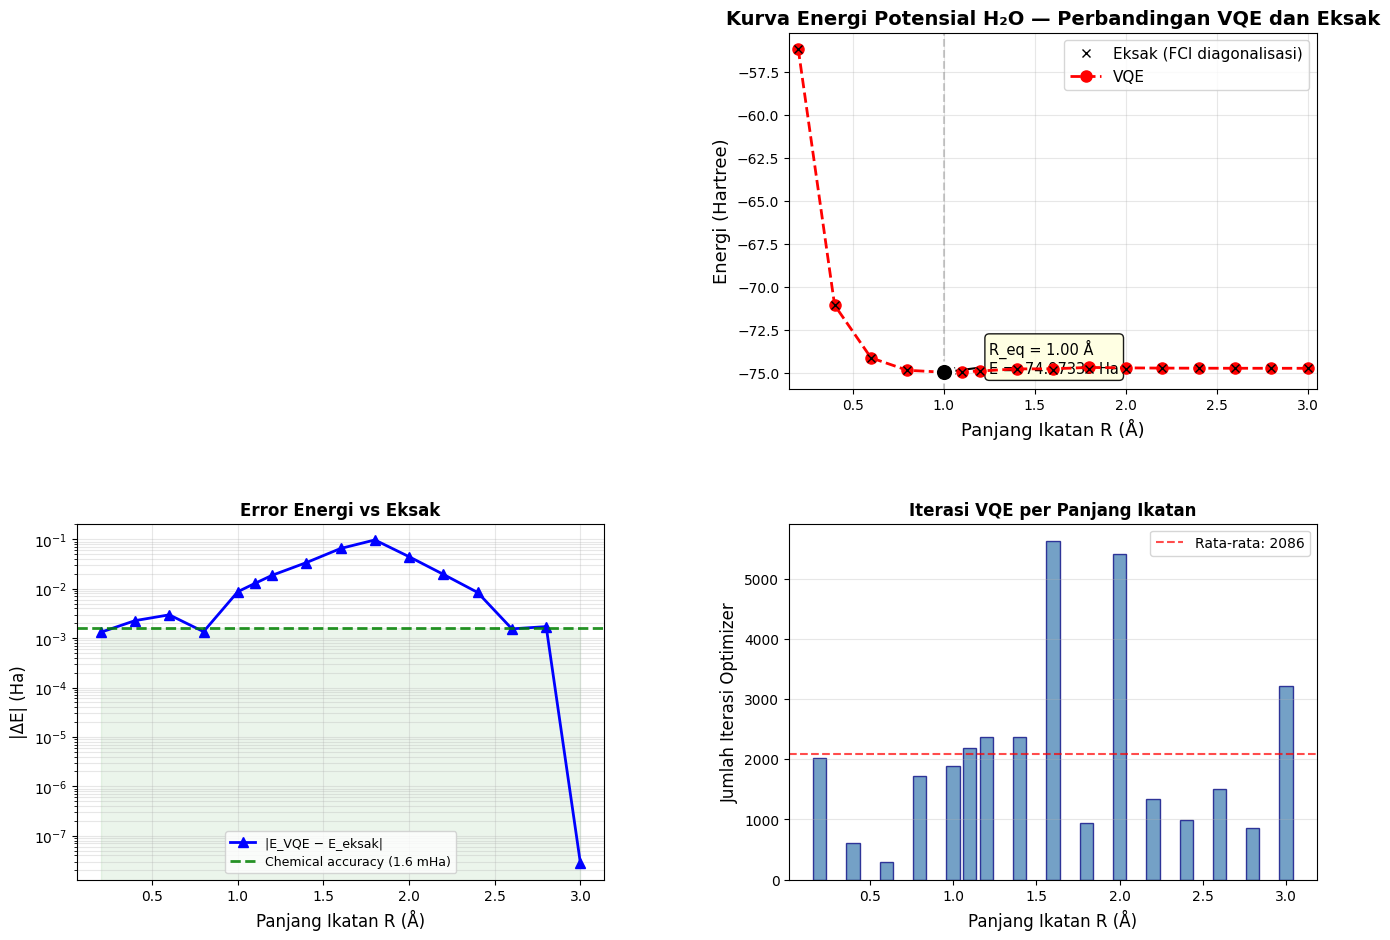

In [52]:
R_arr  = np.array([r['bond_length'] for r in results])
E_ex   = np.array([r['E_exact']     for r in results])
E_vq   = np.array([r['E_vqe']       for r in results])
dv_arr = np.array([r['delta_vqe']   for r in results])
 
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)
 
# ── 1: Kurva energi potensial ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(R_arr, E_ex, 'kx',   lw=2.5, zorder=5, label='Eksak (FCI diagonalisasi)')
ax1.plot(R_arr, E_vq, 'ro--', lw=2.0, ms=8, zorder=4, label='VQE')
 
idx_min = np.argmin(E_ex)
ax1.axvline(R_arr[idx_min], color='gray', ls='--', alpha=0.4, lw=1.5)
ax1.scatter([R_arr[idx_min]], [E_ex[idx_min]], s=180, color='black',
            zorder=10, edgecolor='white', lw=2.5)
ax1.annotate(f'R_eq = {R_arr[idx_min]:.2f} Å\nE = {E_ex[idx_min]:.5f} Ha',
             xy=(R_arr[idx_min], E_ex[idx_min]),
             xytext=(R_arr[idx_min] + 0.25, E_ex[idx_min] - 0.04),
             fontsize=10.5, color='black',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax1.set_xlabel('Panjang Ikatan R (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O — Perbandingan VQE dan Eksak',
              fontsize=14, weight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(R_arr[0] - 0.05, R_arr[-1] + 0.05)
 
# ── 2: Log error vs eksak ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(R_arr, dv_arr, 'b^-', lw=2, ms=7, label='|E_VQE − E_eksak|')
ax2.axhline(1.6e-3, color='green', ls='--', lw=2, alpha=0.85,
            label='Chemical accuracy (1.6 mHa)')
ax2.fill_between(R_arr, 0, 1.6e-3, alpha=0.08, color='green')
ax2.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax2.set_ylabel('|ΔE| (Ha)', fontsize=12)
ax2.set_title('Error Energi vs Eksak', fontsize=12, weight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')
 
# ── 3: Jumlah iterasi VQE ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(R_arr, [r['n_iters_vqe'] for r in results],
        width=0.08, color='steelblue', alpha=0.75, edgecolor='navy')
ax3.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax3.set_ylabel('Jumlah Iterasi Optimizer', fontsize=12)
ax3.set_title('Iterasi VQE per Panjang Ikatan', fontsize=12, weight='bold')
ax3.grid(True, alpha=0.3, axis='y')
 
avg_iters = np.mean([r['n_iters_vqe'] for r in results])
ax3.axhline(avg_iters, color='red', ls='--', lw=1.5, alpha=0.7,
            label=f'Rata-rata: {avg_iters:.0f}')
ax3.legend(fontsize=10)
plt.show()